In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2025-12-11 17:31:42,053 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


  0%|          | 0/160 [00:00<?, ?it/s]

i=15
i=16
i=17
i=18
i=19


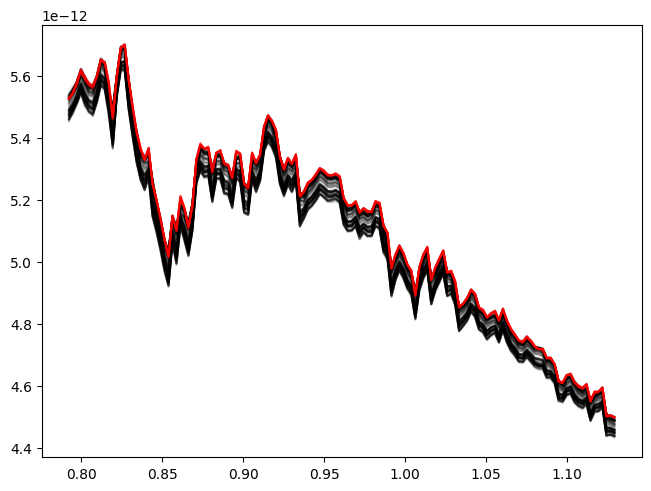

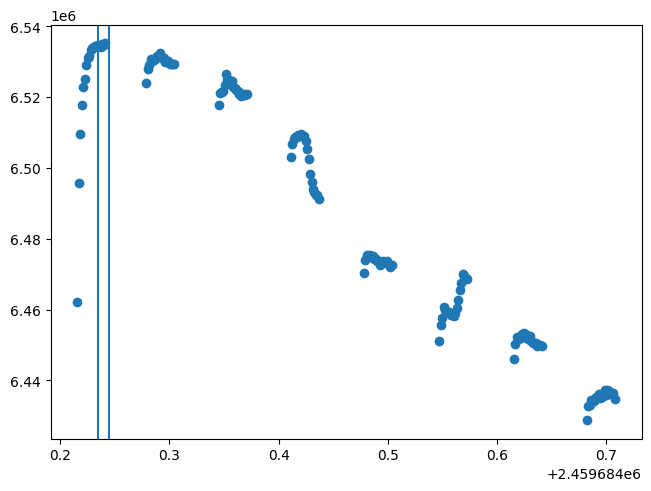

In [31]:
visit = 'S22'

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
avg_lc = _rainbow.get_average_lightcurve()

position = 2459684.24
time_start = position - 0.005
time_end = position + 0.005
for i in range(_rainbow.ntime):
    color='k'
    _alpha = 0.1
    zo = -10*i
    # print(_rainbow.time[i])
    if (_rainbow.time[i].value<=time_end) and (_rainbow.time[i].value>=time_start):
        print(f'i={i}')
        color='red'
        _alpha = 0.5
        zo = 100
    this_spectrum = _rainbow.flux[:,i].value
    e_per_s = this_spectrum / exptime
    e_per_s_per_angstrom = e_per_s / binwidth
    _w, _s, _e = read_sensitivity_curve(grism=grism)
    binned_filter_response = bintogrid(_w.value, _s.value, newx=_rainbow.wavelength.value)['y'] * u.cm**2 / u.erg
    _calibrated_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
    # _rainbow.flux[:,i] = _calibrated_spec.value
    plt.plot(_rainbow.wavelength,_calibrated_spec,c=color,alpha=_alpha,zorder=zo)

# plt.xlim(1.08,1.1)
# plt.ylim(0.9,0.94)

plt.figure()
plt.scatter(_rainbow.time,avg_lc)
plt.axvline(time_start)
plt.axvline(time_end)



/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_45661/482641150.py:73: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


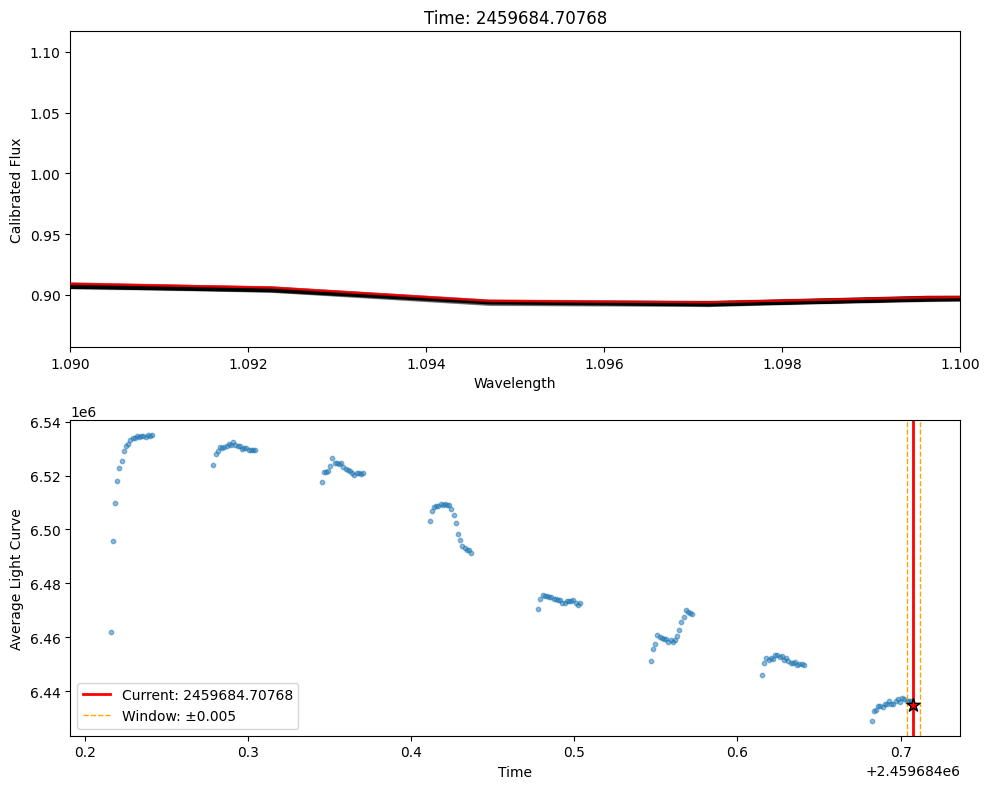

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create a function to generate each frame of the animation
def update_frame(frame_idx):
    """Update function for animation frames."""
    # Clear both subplots
    ax1.clear()
    ax2.clear()
    
    # Set current position based on frame index
    if frame_idx < len(_rainbow.time):
        position = _rainbow.time[frame_idx].value
    else:
        position = _rainbow.time[-1].value
    
    # Set time window around current position
    time_start = position - 0.004
    time_end = position + 0.004
    
    # Plot spectra in first subplot
    for i in range(_rainbow.ntime):
        color = 'k'
        _alpha = 0.1
        zo = -10 * i
        
        # Check if this time is in the current window
        if (_rainbow.time[i].value <= time_end) and (_rainbow.time[i].value >= time_start):
            color = 'red'
            _alpha = 0.5
            zo = 100
            
        # Calculate calibrated spectrum
        this_spectrum = _rainbow.flux[:, i].value
        e_per_s = this_spectrum / exptime
        e_per_s_per_angstrom = e_per_s / binwidth
        
        # Get sensitivity curve and calibrate
        _w, _s, _e = read_sensitivity_curve(grism=grism)
        binned_filter_response = bintogrid(_w.value, _s.value, newx=_rainbow.wavelength.value)['y'] * u.cm**2 / u.erg
        _calibrated_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
        
        # Plot this spectrum
        ax1.plot(_rainbow.wavelength, _calibrated_spec/np.nanmedian(_calibrated_spec), c=color, alpha=_alpha, zorder=zo)

    
    # Customize first subplot
    ax1.set_xlabel('Wavelength')
    ax1.set_ylabel('Calibrated Flux')
    ax1.set_xlim(1.09,1.10)
    ax1.set_title(f'Time: {position:.5f}')
    
    # Plot light curve in second subplot
    ax2.scatter(_rainbow.time, avg_lc, alpha=0.5, s=10)
    
    # Highlight current position and time window
    ax2.axvline(position, color='red', linestyle='-', linewidth=2, label=f'Current: {position:.5f}')
    ax2.axvline(time_start, color='orange', linestyle='--', linewidth=1, label=f'Window: ±0.005')
    ax2.axvline(time_end, color='orange', linestyle='--', linewidth=1)
    
    # Highlight the current point in the light curve
    current_idx = np.argmin(np.abs(_rainbow.time.value - position))
    ax2.scatter(_rainbow.time[current_idx], avg_lc[current_idx], 
                color='red', s=100, marker='*', edgecolor='black', zorder=5)
    
    # Customize second subplot
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Average Light Curve')
    ax2.legend(loc='best')
    
    # Adjust layout
    plt.tight_layout()
    
    return [ax1, ax2]

# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Create the animation
# Adjust 'interval' to control speed (milliseconds between frames)
# Adjust 'frames' to control how many frames (can use len(_rainbow.time) for all times)
ani = FuncAnimation(fig, update_frame, 
                    frames=len(_rainbow.time),  # Use all time points
                    interval=100,  # 100 ms between frames
                    repeat=False,  # Don't loop
                    blit=False)  # Don't use blitting for complex plots

# To save the animation as a video file (requires ffmpeg or imagemagick):
# ani.save('time_domain_movie.mp4', writer='ffmpeg', fps=10, dpi=100)

# To save as an animated GIF:
ani.save('time_domain_movie.gif', writer='pillow', fps=10)

plt.tight_layout()
plt.show()